In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Retreiving the dataset
group1_df = pd.read_csv("data/KSI_Project Dataset.csv")


In [4]:
group1_df.head(5)

,OBJECTID,INDEX,ACCNUM,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,...,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION,x,y
0,1,3389067,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
1,2,3389068,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
2,3,3389069,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
3,4,3389070,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
4,5,3389071,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06


In [5]:
group1_df.shape

(18957, 54)

In [6]:
# Columns findings
group1_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  object 
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  object 
 6   STREET2            17251 non-null  object 
 7   OFFSET             3820 non-null   object 
 8   ROAD_CLASS         18471 non-null  object 
 9   DISTRICT           18728 non-null  object 
 10  LATITUDE           18957 non-null  float64
 11  LONGITUDE          18957 non-null  float64
 12  ACCLOC             13501 non-null  object 
 13  TRAFFCTL           18882 non-null  object 
 14  VISIBILITY         18933 non-null  object 
 15  LIGHT              18953 non-null  object 
 16  RDSFCOND           189

In [7]:
# null values :
group1_df.isnull().sum().sum()

np.int64(384930)

In [8]:
null_cols = group1_df.columns[group1_df.isnull().any()]     # any columns which has null values
(group1_df[null_cols].isnull().sum()/18957)*100    # Total nulls in each of them.

ACCNUM           26.006225
STREET2           8.999314
OFFSET           79.849132
ROAD_CLASS        2.563697
DISTRICT          1.207997
ACCLOC           28.780925
TRAFFCTL          0.395632
VISIBILITY        0.126602
LIGHT             0.021100
RDSFCOND          0.152978
ACCLASS           0.005275
IMPACTYPE         0.142428
INVTYPE           0.084402
INJURY           46.932532
FATAL_NO         95.410666
INITDIR          27.836683
VEHTYPE          18.394261
MANOEUVER        41.952841
DRIVACT          49.000369
DRIVCOND         49.010919
PEDTYPE          82.966714
PEDACT           82.977264
PEDCOND          82.877038
CYCLISTYPE       95.753548
CYCACT           95.769373
CYCCOND          95.779923
PEDESTRIAN       59.445060
CYCLIST          89.523659
AUTOMOBILE        9.110091
MOTORCYCLE       91.116738
TRUCK            93.833412
TRSN_CITY_VEH    93.944189
EMERG_VEH        99.741520
PASSENGER        62.108983
SPEEDING         85.788891
AG_DRIV          48.114153
REDLIGHT         91.681173
A

In [9]:
len(null_cols)      # 39 columns have null values alteast once or more than it 

39

In [10]:
group1_df.nunique()  # finding the target column

OBJECTID             18957
INDEX                18957
ACCNUM                4955
DATE                  4128
TIME                  1341
STREET1               1942
STREET2               2822
OFFSET                 494
ROAD_CLASS              11
DISTRICT                 4
LATITUDE              4783
LONGITUDE             5202
ACCLOC                  10
TRAFFCTL                10
VISIBILITY               8
LIGHT                    9
RDSFCOND                 9
ACCLASS                  3
IMPACTYPE               10
INVTYPE                 19
INVAGE                  21
INJURY                   4
FATAL_NO                78
INITDIR                  5
VEHTYPE                 32
MANOEUVER               16
DRIVACT                 13
DRIVCOND                10
PEDTYPE                 16
PEDACT                  15
PEDCOND                 10
CYCLISTYPE              22
CYCACT                  11
CYCCOND                 10
PEDESTRIAN               1
CYCLIST                  1
AUTOMOBILE               1
M

In [11]:
group1_df['ACCLASS'].unique() # Target columns

array(['Non-Fatal Injury', 'Fatal', 'Property Damage O', nan],
      dtype=object)

In [12]:
group1_df['ACCLASS'].value_counts()

ACCLASS
Non-Fatal Injury     16268
Fatal                 2670
Property Damage O       18
Name: count, dtype: int64

In [13]:
# basic statistics
group1_df.describe()

,OBJECTID,INDEX,ACCNUM,TIME,LATITUDE,LONGITUDE,FATAL_NO,x,y
count,18957.000000,1.895700e+04,1.402700e+04,18957.000000,18957.000000,18957.000000,870.000000,18957.000000,1.895700e+04
mean,9479.000000,3.994181e+07,5.576714e+08,1364.956428,43.710299,-79.396490,28.752874,629181.568576,4.840951e+06
std,5472.558862,3.749731e+07,1.180026e+09,631.310388,0.056294,0.104484,17.657001,8364.337712,6.324585e+03
min,1.000000,3.363207e+06,2.530100e+04,0.000000,43.589678,-79.638390,1.000000,609625.702600,4.827328e+06
25%,4740.000000,5.408154e+06,1.034561e+06,924.000000,43.661727,-79.471469,14.000000,623177.000800,4.835532e+06
50%,9479.000000,7.820656e+06,1.220029e+06,1450.000000,43.702346,-79.397388,27.500000,629199.077800,4.840070e+06
75%,14218.000000,8.092292e+07,1.386958e+06,1852.000000,43.755945,-79.318286,42.000000,635424.041900,4.846036e+06
max,18957.000000,8.180752e+07,4.008024e+09,2359.000000,43.855445,-79.122974,78.000000,651024.087800,4.857444e+06


In [14]:
group1_df.describe(include='object')


,DATE,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,...,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION
count,18957,18957,17251,3820,18471,18728,13501,18882,18933,18953,...,2694,9836,1577,808,493,18957,18957,18957,18957,18957
unique,4128,1942,2822,494,11,4,10,10,8,9,...,1,1,1,1,1,159,159,141,141,17
top,8/17/2014 8:00:00 AM,YONGE ST,BATHURST ST,10 m West of,Major Arterial,Toronto and East York,At Intersection,No Control,Clear,Daylight,...,Yes,Yes,Yes,Yes,Yes,1,West Humber-Clairville,77,Waterfront Communities-The Island (77),D42
freq,35,403,156,61,13376,6328,8774,9021,16373,10779,...,2694,9836,1577,808,493,597,597,740,740,1813


In [15]:
group1_df['FATAL'] = group1_df['FATAL_NO'].apply(lambda x: 1 if x > 0 else 0) #If 1 it is fatal, if 0 it is non-fatal

In [16]:
missing = group1_df.isnull().sum()
missing_percent = (missing / len(group1_df)) * 100

In [17]:
#Finding the missing data

# Missing values count
missing = group1_df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

In [18]:
print(missing_df)

                   Missing Count  Missing %
EMERG_VEH                  18908  99.741520
DISABILITY                 18464  97.399378
CYCCOND                    18157  95.779923
CYCACT                     18155  95.769373
CYCLISTYPE                 18152  95.753548
ALCOHOL                    18149  95.737722
FATAL_NO                   18087  95.410666
TRSN_CITY_VEH              17809  93.944189
TRUCK                      17788  93.833412
REDLIGHT                   17380  91.681173
MOTORCYCLE                 17273  91.116738
CYCLIST                    16971  89.523659
SPEEDING                   16263  85.788891
PEDACT                     15730  82.977264
PEDTYPE                    15728  82.966714
PEDCOND                    15711  82.877038
OFFSET                     15137  79.849132
PASSENGER                  11774  62.108983
PEDESTRIAN                 11269  59.445060
DRIVCOND                    9291  49.010919
DRIVACT                     9289  49.000369
AG_DRIV                     9121

In [19]:
sns.set(style="whitegrid")

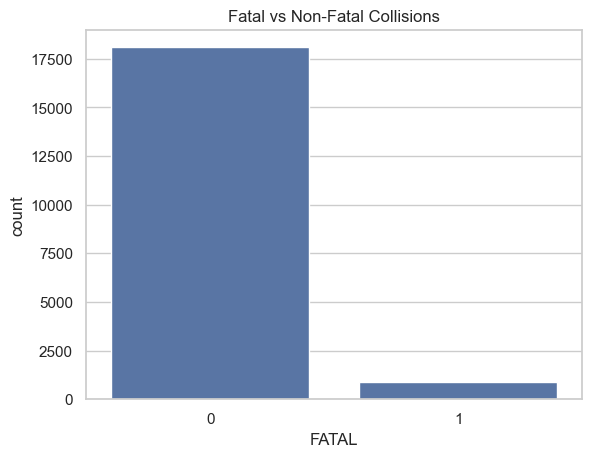

In [20]:
sns.countplot(data=group1_df, x='FATAL')
plt.title("Fatal vs Non-Fatal Collisions")
plt.show()

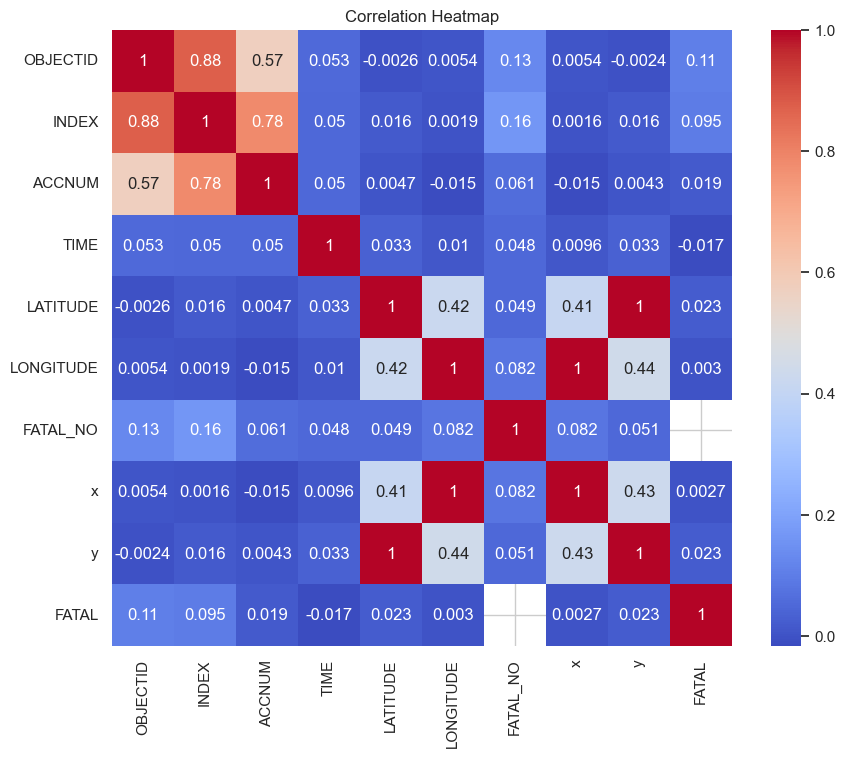

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(group1_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

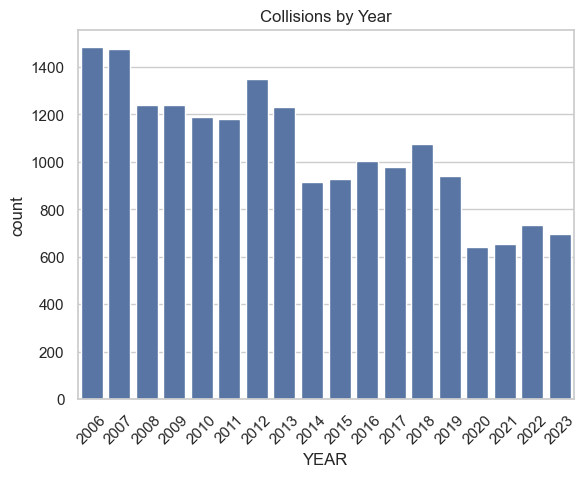

In [22]:
group1_df['YEAR'] = pd.to_datetime(group1_df['DATE']).dt.year

sns.countplot(data=group1_df, x='YEAR')
plt.xticks(rotation=45)
plt.title("Collisions by Year")
plt.show()

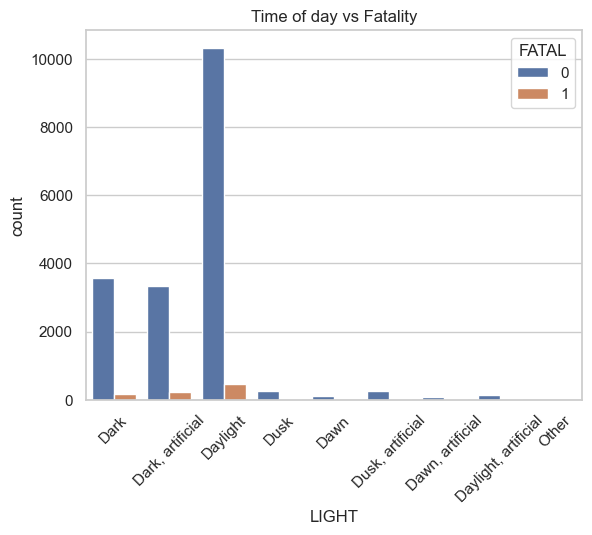

In [23]:
sns.countplot(data=group1_df, x='LIGHT', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Time of day vs Fatality")
plt.show()

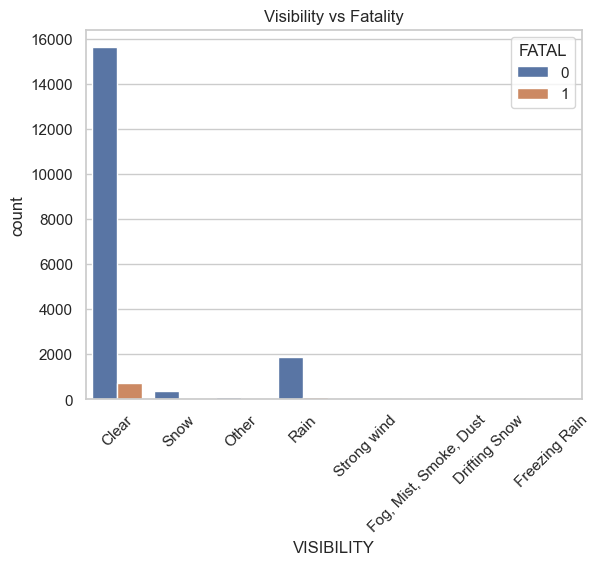

In [24]:
sns.countplot(data=group1_df, x='VISIBILITY', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Visibility vs Fatality")
plt.show()

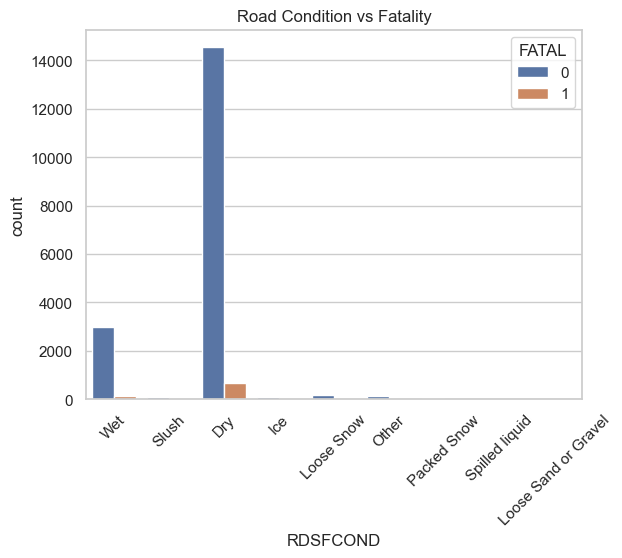

In [25]:
sns.countplot(data=group1_df, x='RDSFCOND', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Road Condition vs Fatality")
plt.show()

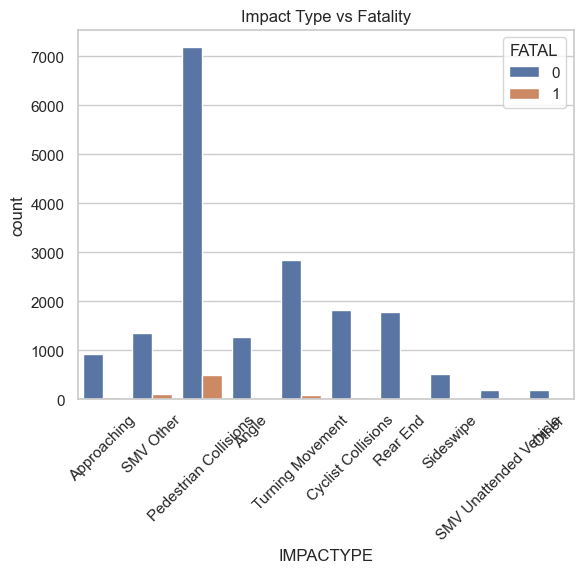

In [26]:
sns.countplot(data=group1_df, x='IMPACTYPE', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Impact Type vs Fatality")
plt.show()

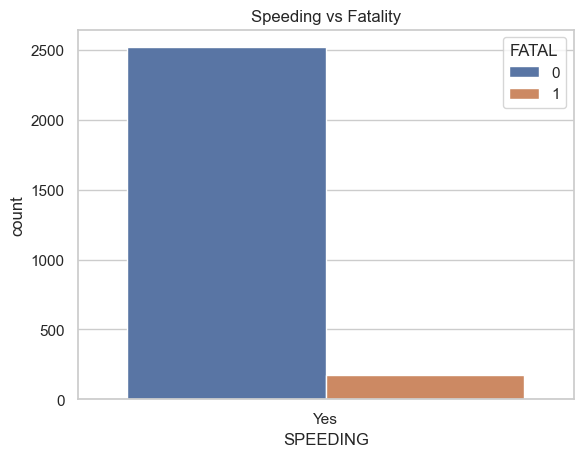

In [27]:
sns.countplot(data=group1_df, x='SPEEDING', hue='FATAL')
plt.title("Speeding vs Fatality")
plt.show()

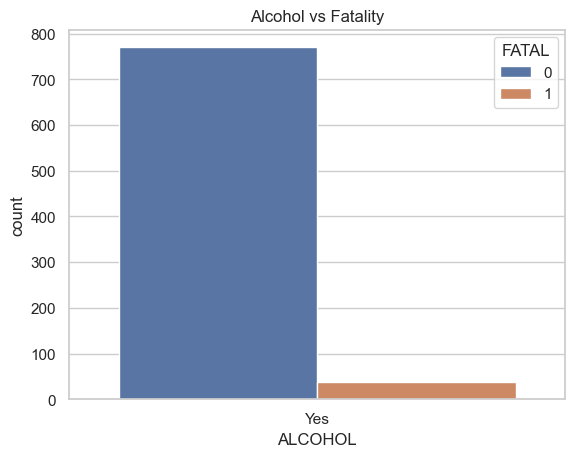

In [28]:
sns.countplot(data=group1_df, x='ALCOHOL', hue='FATAL')
plt.title("Alcohol vs Fatality")
plt.show()

In [29]:
age_order = [
    '0 to 4', '5 to 9', '10 to 14', '15 to 19',
    '20 to 24', '25 to 29', '30 to 34', '35 to 39',
    '40 to 44', '45 to 49', '50 to 54', '55 to 59',
    '60 to 64', '65 to 69', '70 to 74', '75 to 79',
    '80 to 84', '85 to 89', '90 to 94'
]

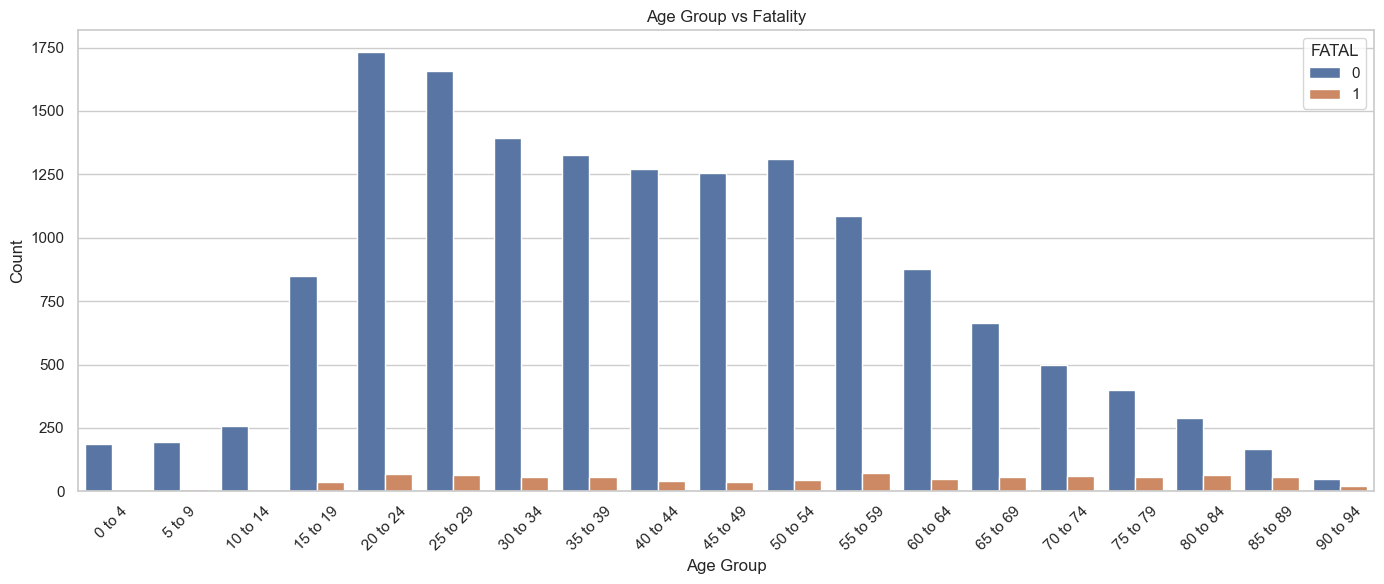

In [30]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=group1_df,
    x='INVAGE',
    hue='FATAL',
    order=age_order
)

plt.xticks(rotation=45)
plt.title("Age Group vs Fatality")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Dropping columns 

In [31]:
drop_columns = [
  "EMERG_VEH",
  "DISABILITY",
  "CYCCOND",
  "CYCACT",
  "CYCLISTYPE",
  "FATAL_NO",
  "TRSN_CITY_VEH",
  "TRUCK",
  
  "MOTORCYCLE",
  "CYCLIST",
  
  "PEDACT",
  "PEDTYPE",
  "PEDCOND",
  "OFFSET",
  "PASSENGER",
  "PEDESTRIAN",
  "DRIVCOND",
  "DRIVACT",
  "INJURY",
  "MANOEUVER"
]
group1_df['ACCLASS'].dropna(axis=0)

0        Non-Fatal Injury
1        Non-Fatal Injury
2        Non-Fatal Injury
3        Non-Fatal Injury
4        Non-Fatal Injury
               ...       
18952    Non-Fatal Injury
18953               Fatal
18954               Fatal
18955    Non-Fatal Injury
18956    Non-Fatal Injury
Name: ACCLASS, Length: 18956, dtype: object

In [32]:
group1_df = group1_df.drop(drop_columns, axis=1)

#### Converting some columns with missing values Yes and NaN with 0 and 1

In [33]:
binary_columns = ['ALCOHOL', 'SPEEDING', 'REDLIGHT', 'AG_DRIV']

In [34]:
group1_df[binary_columns] = group1_df[binary_columns].fillna(0) # Fill NaN -> 0

In [35]:
group1_df[binary_columns]= (group1_df[binary_columns]=="Yes").astype(int)  # Fill yes with 1

In [36]:
group1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  object 
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  object 
 6   STREET2            17251 non-null  object 
 7   ROAD_CLASS         18471 non-null  object 
 8   DISTRICT           18728 non-null  object 
 9   LATITUDE           18957 non-null  float64
 10  LONGITUDE          18957 non-null  float64
 11  ACCLOC             13501 non-null  object 
 12  TRAFFCTL           18882 non-null  object 
 13  VISIBILITY         18933 non-null  object 
 14  LIGHT              18953 non-null  object 
 15  RDSFCOND           18928 non-null  object 
 16  ACCLASS            189

In [37]:
cols_with_nulls = group1_df.columns[group1_df.isnull().any()].tolist()


In [38]:
# Filling missing values of categorical with mode 
row_modes = group1_df[cols_with_nulls].mode(axis=1)[0]

for col in cols_with_nulls:
    group1_df[col] = group1_df[col].fillna(row_modes)

C:\Users\Raiha\AppData\Local\Temp\ipykernel_12068\311209778.py:2: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'float'
  row_modes = group1_df[cols_with_nulls].mode(axis=1)[0]


In [39]:
group1_df.isnull().sum()  # now there is no missing values 

OBJECTID             0
INDEX                0
ACCNUM               0
DATE                 0
TIME                 0
STREET1              0
STREET2              0
ROAD_CLASS           0
DISTRICT             0
LATITUDE             0
LONGITUDE            0
ACCLOC               0
TRAFFCTL             0
VISIBILITY           0
LIGHT                0
RDSFCOND             0
ACCLASS              0
IMPACTYPE            0
INVTYPE              0
INVAGE               0
INITDIR              0
VEHTYPE              0
AUTOMOBILE           0
SPEEDING             0
AG_DRIV              0
REDLIGHT             0
ALCOHOL              0
HOOD_158             0
NEIGHBOURHOOD_158    0
HOOD_140             0
NEIGHBOURHOOD_140    0
DIVISION             0
x                    0
y                    0
FATAL                0
YEAR                 0
dtype: int64

In [40]:
idx = group1_df[group1_df['ACCLASS'] == "Yes"].index
group1_df = group1_df.drop(idx)

In [41]:
group1_df['ACCLASS'].unique()

array(['Non-Fatal Injury', 'Fatal', 'Property Damage O', 3001623085.0],
      dtype=object)

In [42]:
group1_df[group1_df['ACCLASS'] == 'Property Damage O']


,OBJECTID,INDEX,ACCNUM,DATE,TIME,STREET1,STREET2,ROAD_CLASS,DISTRICT,LATITUDE,...,ALCOHOL,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION,x,y,FATAL,YEAR
16129,16130,81471712,"Automobile, Station Wagon",11/24/2019 10:00:00 AM,257,3207 KINGSTON RD,"Automobile, Station Wagon",Major Arterial,Scarborough,43.729338,...,0,123,Cliffcrest,123,Cliffcrest (123),D43,642757.7480,4.843337e+06,0,2019
16130,16131,81471713,"Automobile, Station Wagon",11/24/2019 10:00:00 AM,257,3207 KINGSTON RD,"Automobile, Station Wagon",Major Arterial,Scarborough,43.729338,...,0,123,Cliffcrest,123,Cliffcrest (123),D43,642757.7480,4.843337e+06,0,2019
16753,16754,81588165,1940250.0,10/12/2020 8:00:00 AM,2250,MCCOWAN RD,BRIDLEY DR,Major Arterial,Scarborough,43.815261,...,0,129,Agincourt North,129,Agincourt North (129),D42,639067.6231,4.852807e+06,0,2020
16754,16755,81588166,1940250.0,10/12/2020 8:00:00 AM,2250,MCCOWAN RD,BRIDLEY DR,Major Arterial,Scarborough,43.815261,...,0,129,Agincourt North,129,Agincourt North (129),D42,639067.6231,4.852807e+06,0,2020
16755,16756,81588167,1940250.0,10/12/2020 8:00:00 AM,2250,MCCOWAN RD,BRIDLEY DR,Major Arterial,Scarborough,43.815261,...,0,129,Agincourt North,129,Agincourt North (129),D42,639067.6231,4.852807e+06,0,2020
16756,16757,81588168,1940250.0,10/12/2020 8:00:00 AM,2250,MCCOWAN RD,BRIDLEY DR,Major Arterial,Scarborough,43.815261,...,0,129,Agincourt North,129,Agincourt North (129),D42,639067.6231,4.852807e+06,0,2020
17547,17548,81680743,2000130290.0,1/20/2022 10:00:00 AM,1910,1875 STEELES AVE W,2000130290.0,Major Arterial,North York,43.787585,...,0,34,Bathurst Manor,34,Bathurst Manor (34),D32,623260.2761,4.849420e+06,0,2022
17548,17549,81680744,2000130290.0,1/20/2022 10:00:00 AM,1910,1875 STEELES AVE W,2000130290.0,Major Arterial,North York,43.787585,...,0,34,Bathurst Manor,34,Bathurst Manor (34),D32,623260.2761,4.849420e+06,0,2022
17901,17902,81663855,2001504296.0,8/5/2022 8:00:00 AM,1640,DUPONT ST,OSSINGTON AVE,Major Arterial,Etobicoke York,43.670024,...,0,172,Dovercourt Village,93,Dovercourt-Wallace Emerson-Junction (93),D14,626651.4172,4.836422e+06,0,2022
17902,17903,81663856,2001504296.0,8/5/2022 8:00:00 AM,1640,DUPONT ST,OSSINGTON AVE,Major Arterial,Etobicoke York,43.670024,...,0,172,Dovercourt Village,93,Dovercourt-Wallace Emerson-Junction (93),D14,626651.4172,4.836422e+06,0,2022


In [43]:
mapping = {
    'non-fatal injury': 0,
    'fatal': 1
}

# Step 1: normalize text
group1_df['ACCLASS'] = (
    group1_df['ACCLASS']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Step 2: keep ONLY desired classes
group1_df = group1_df[
    group1_df['ACCLASS'].isin(mapping.keys())
]

# Step 3: map to numbers
group1_df['ACCLASS'] = group1_df['ACCLASS'].map(mapping)

In [44]:
group1_df['ACCLASS'].unique()

array([0, 1])

## chi-2 square technique for finding the correlated columns

In [45]:

cat_cols = group1_df.select_dtypes(include='object').columns.to_list()


In [46]:
group1_df[cat_cols] = group1_df[cat_cols].astype(str)
from scipy.stats import chi2_contingency

In [47]:
from scipy.stats import chi2_contingency
import pandas as pd

results = []

# get all categorical columns except target
cat_cols = group1_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'ACCLASS']

for col in cat_cols:
    crosstab = pd.crosstab(index=group1_df[col], columns=group1_df['ACCLASS'])
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    
    results.append({
        'Feature': col,
        'Chi2 Score': round(chi2, 4),
        'P-Value': round(p_value, 4),
        'Degrees of Freedom': dof
    })

chi2_df = pd.DataFrame(results).sort_values('Chi2 Score', ascending=False)
print(chi2_df)

              Feature  Chi2 Score  P-Value  Degrees of Freedom
0              ACCNUM  14097.9971      0.0                5105
1                DATE  12612.5972      0.0                4123
3             STREET2   8956.3044      0.0                3276
6              ACCLOC   5538.2428      0.0                1824
2             STREET1   4879.4218      0.0                1937
14            INITDIR   4243.7352      0.0                2452
15            VEHTYPE   2873.9371      0.0                1205
16         AUTOMOBILE   2051.6926      0.0                 597
17           HOOD_158    766.9244      0.0                 158
18  NEIGHBOURHOOD_158    766.9244      0.0                 158
19           HOOD_140    708.1071      0.0                 140
20  NEIGHBOURHOOD_140    708.1071      0.0                 140
4          ROAD_CLASS    517.7238      0.0                 152
11          IMPACTYPE    403.2032      0.0                  18
5            DISTRICT    242.6090      0.0             

In [48]:
good_features = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
bad_features  = chi2_df[chi2_df['P-Value'] > 0.05]['Feature'].tolist()

print("Keep:", good_features)
print("Drop:", bad_features)

Keep: ['ACCNUM', 'DATE', 'STREET2', 'ACCLOC', 'STREET1', 'INITDIR', 'VEHTYPE', 'AUTOMOBILE', 'HOOD_158', 'NEIGHBOURHOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT', 'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY', 'DIVISION', 'TRAFFCTL', 'LIGHT']
Drop: []


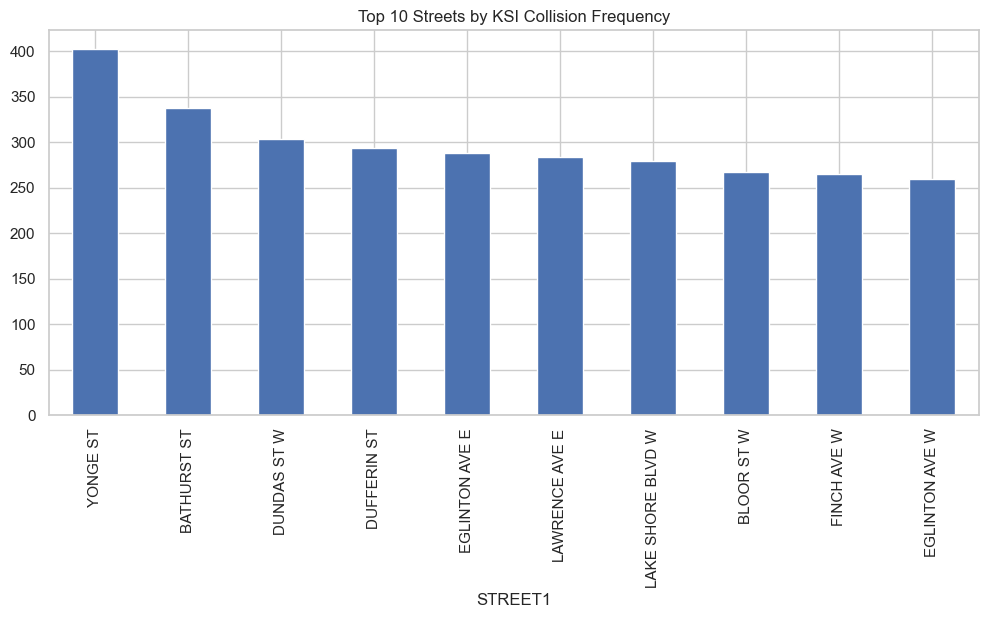

In [49]:
# Show this as an EDA insight only
top_streets = group1_df['STREET1'].value_counts().head(10)
top_streets.plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Streets by KSI Collision Frequency")
plt.show()

In [50]:

print(group1_df['HOOD_158'].nunique())
print(group1_df['HOOD_140'].nunique())
print(group1_df['NEIGHBOURHOOD_158'].nunique())
print(group1_df['NEIGHBOURHOOD_140'].nunique())

print(group1_df[['HOOD_158', 'HOOD_140', 
          'NEIGHBOURHOOD_158', 'NEIGHBOURHOOD_140']].head(20))

159
141
159
141
   HOOD_158 HOOD_140     NEIGHBOURHOOD_158          NEIGHBOURHOOD_140
0        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
1        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
2        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
3        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
4        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
5        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
6        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
7        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
8        64       64     Woodbine Corridor     Woodbine Corridor (64)
9        64       64     Woodbine Corridor     Woodbine Corridor (64)
10       64       64     Woodbine Corridor     Woodbine Corridor (64)
11       64       64     Woodbine Corridor     Woodbine Corridor (64)
12       64       64     Woodbine Corridor     Woodbine Corridor (64)
13  

In [51]:

dropping = [
    'ACCNUM',            # just a row ID number
    'DATE',              # already extracted to YEAR/MONTH/HOUR
    'STREET1',           # text street name, too many unique values
    'STREET2',           # same issue
    'HOOD_158',          # redundant with HOOD_140
    'NEIGHBOURHOOD_158', # redundant with NEIGHBOURHOOD_140
    'NEIGHBOURHOOD_140', # too many unique text values
]

In [52]:
good_features =  [
    'VEHTYPE', 'INITDIR', 'AUTOMOBILE', 'ACCLOC',
    'HOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT',
    'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY',
    'DIVISION', 'LIGHT', 'TRAFFCTL'
]

In [53]:
# Convert to datetime 
group1_df['DATE'] = pd.to_datetime(group1_df['DATE'])


group1_df['YEAR']        = group1_df['DATE'].dt.year
group1_df['MONTH']       = group1_df['DATE'].dt.month
group1_df['HOUR']        = group1_df['DATE'].dt.hour
group1_df['DAY_OF_WEEK'] = group1_df['DATE'].dt.dayofweek


group1_df = group1_df.drop(columns=['DATE'])
# Dropping the third category as it is very minimal and can confuse the model



In [100]:
final_features = good_features + ['YEAR', 'MONTH', 'HOUR', 
                                   'DAY_OF_WEEK', 'SPEEDING', 
                                   'ALCOHOL', 'AG_DRIV']

group1_df = group1_df.dropna(subset=['ACCLASS'])


X = group1_df[final_features]
y = group1_df['ACCLASS']

print("Final shape:", X.shape)

Final shape: (18938, 22)


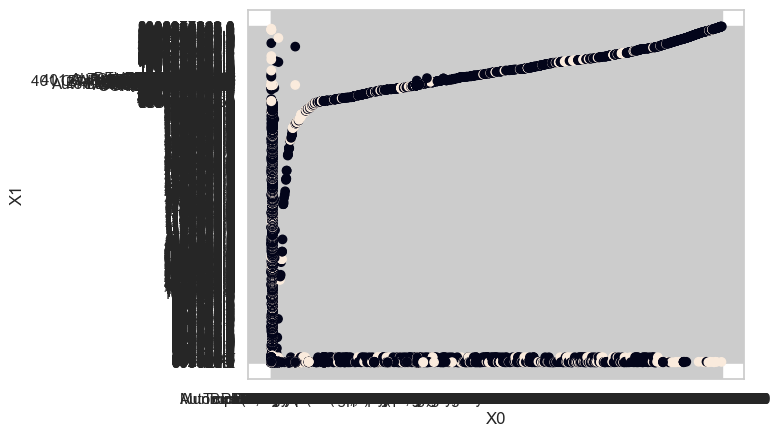

In [105]:
plt.scatter(X.values[:, 0], X.values[:, 1], c=y)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()


# Fixing the cat cols , grouping for One Hot Encoder

In [55]:
cat_cols_final = X.select_dtypes('object').columns;
cat_cols_final
len(cat_cols_final)

15

In [56]:
# finding the unique catgories for eahch of the cat cols
for col in cat_cols_final:
    print(f"{col}: {X[col].nunique()} unique values")
    print(X[col].value_counts().to_string())
    print("---")

VEHTYPE: 1206 unique values
VEHTYPE
Automobile, Station Wagon         7797
Other                             4766
At Intersection                    824
Bicycle                            819
Motorcycle                         747
Clear                              537
Municipal Transit Bus (TTC)        283
Pick Up Truck                      269
Truck - Open                       182
Passenger Van                      143
Angle                              100
Delivery Van                        87
Approaching                         83
At/Near Private Drive               80
Truck - Closed (Blazer, etc)        71
Street Car                          52
Truck - Dump                        52
Dark, artificial                    43
Truck-Tractor                       42
Taxi                                28
Moped                               24
Daylight                            22
Truck (other)                       20
Bus (Other) (Go Bus, Gray Coa       19
4002717713.0                

In [57]:
""" Grouping the cat columsn fixing the cat data in top N cats  """
def group_categorical_columns(series, top_n=7, rare_thresh=0.01):
    s = series.astype(str).str.strip().str.lower()
    
    # Step 2: remove numeric-like junk
    s = s.apply(lambda x: 'unknown' if x.replace('.', '', 1).isdigit() else x)
    
    # Step 3: get frequencies
    freq = s.value_counts(normalize=True)
    
    # Step 4: keep top categories OR above threshold
    keep = freq[(freq > rare_thresh)].index
    
    # fallback: if too many still, keep top_n
    if len(keep) > top_n:
        keep = freq.nlargest(top_n).index
    
    # Step 5: group rest
    s = s.apply(lambda x: x if x in keep else 'other')
    
    return s

In [58]:
# Applying the cleaning and group to every columns

for col in cat_cols_final:
    X[col] = group_categorical_columns(X[col])

C:\Users\Raiha\AppData\Local\Temp\ipykernel_12068\1094245900.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = group_categorical_columns(X[col])
C:\Users\Raiha\AppData\Local\Temp\ipykernel_12068\1094245900.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = group_categorical_columns(X[col])
C:\Users\Raiha\AppData\Local\Temp\ipykernel_12068\1094245900.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [59]:
# SHowing the fixed columns and unique values 
for col in cat_cols_final:
    print(f"{col}: {X[col].nunique()} unique values")
    print(X[col].value_counts().to_string())
    print("---")

VEHTYPE: 7 unique values
VEHTYPE
automobile, station wagon    7797
other                        6666
unknown                      1548
at intersection               824
bicycle                       819
motorcycle                    747
clear                         537
---
INITDIR: 8 unique values
INITDIR
unknown            4623
east               3384
west               3335
south              3222
north              3200
other               532
at intersection     383
clear               259
---
AUTOMOBILE: 3 unique values
AUTOMOBILE
yes        17215
unknown     1255
other        468
---
ACCLOC: 6 unique values
ACCLOC
at intersection          8773
unknown                  5249
non intersection         2646
intersection related     1600
at/near private drive     407
other                     263
---
HOOD_140: 2 unique values
HOOD_140
unknown    18784
other        154
---
ROAD_CLASS: 6 unique values
ROAD_CLASS
major arterial    13371
minor arterial     2957
collector          1032
loc

## Fixed the grouping columns

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15150, 22)
Test size: (3788, 22)


In [61]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['VEHTYPE', 'INITDIR', 'AUTOMOBILE', 'ACCLOC', 'HOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT', 'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY', 'DIVISION', 'LIGHT', 'TRAFFCTL']
Numerical: ['YEAR', 'MONTH', 'HOUR', 'DAY_OF_WEEK', 'SPEEDING', 'ALCOHOL', 'AG_DRIV']


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [63]:
# numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [64]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [65]:
import imblearn
from imblearn.over_sampling import SMOTENC

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [66]:
cat_indices = list(range(len(cat_cols)))

smote = SMOTENC(random_state=42, categorical_features=cat_indices)

X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

In [67]:
print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())

Before balancing:
 ACCLASS
0    13014
1     2136
Name: count, dtype: int64

After balancing:
 ACCLASS
1    13014
0    13014
Name: count, dtype: int64


# Do not change anything before this tab

# Mohammednaeem have used mn instead of firstname in his variables

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
# Initialize the Random Forest Classifier
rf_model_mn = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model_mn.fit(X_resampled, y_resampled)

# Make predictions on the processed test set
y_pred_mn = rf_model_mn.predict(X_test_processed)

Accuracy Score: 0.8862


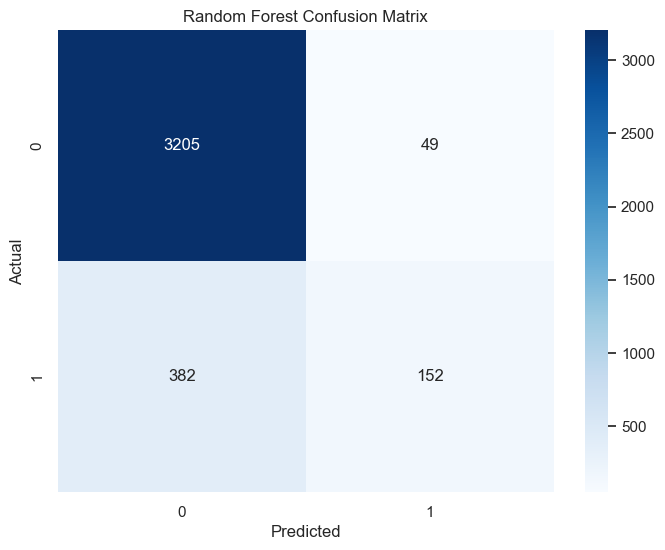


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94      3254
           1       0.76      0.28      0.41       534

    accuracy                           0.89      3788
   macro avg       0.82      0.63      0.68      3788
weighted avg       0.87      0.89      0.86      3788



In [70]:
# Print Accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_mn):.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_mn), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mn))

In [71]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

# Initialize GridSearch
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=89), 
                           param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2)

# Fit GridSearch
grid_search.fit(X_resampled, y_resampled)

print(f"Best Parameters: {grid_search.best_params_}")

# Use the best model for final prediction
best_rf_mn = grid_search.best_estimator_
y_pred_best_mn = best_rf_mn.predict(X_test_processed)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [72]:
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


Final Model Evaluation (Tuned)
Accuracy: 0.8875

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      3254
           1       0.75      0.30      0.43       534

    accuracy                           0.89      3788
   macro avg       0.83      0.64      0.68      3788
weighted avg       0.88      0.89      0.87      3788



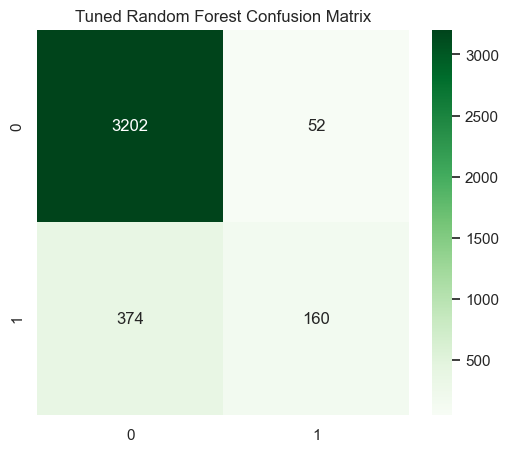

In [73]:
# Evaluation Metrics
print("Final Model Evaluation (Tuned)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_mn):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_mn))

# Plot the new Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best_mn), annot=True, fmt='d', cmap='Greens')
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

In [74]:
import joblib
import os

os.makedirs('./model_mn', exist_ok=True)

# Save the best model to a file
joblib.dump(best_rf_mn, './model_mn/random_forest_ksi_model.pkl')

# Also save the scaler if you used one, as the API will need it to process new input
# joblib.dump(scaler, 'scaler.pkl') 

print("Model saved as 'random_forest_ksi_model.pkl'")

Model saved as 'random_forest_ksi_model.pkl'


# This is mohammednaeem's part 👆 (random forest)

## Decision Tree Model 

In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn import tree
import matplotlib.pyplot as plt
import pickle
import os

In [76]:
dt_baseline = DecisionTreeClassifier(
    criterion='entropy',
    random_state=77
)

dt_baseline.fit(X_resampled, y_resampled)

DecisionTreeClassifier(criterion='entropy', random_state=77)

In [77]:
cv_scores = cross_val_score(
    dt_baseline,
    X_resampled,
    y_resampled,
    cv=5,
    scoring='f1'
)

print("Baseline 5-fold CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Baseline 5-fold CV F1 scores: [0.66859206 0.91167883 0.90989172 0.91543027 0.91481141]
Mean CV F1: 0.8640808575473015


In [78]:
param_grid = {
    'criterion': ['entropy', 'gini'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 30, 50]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=77),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_resampled, y_resampled)

best_dt = grid_dt.best_estimator_

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.8677222622464729


In [79]:
y_pred = best_dt.predict(X_test_processed)

In [80]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8291974656810982
Precision: 0.4118564742589704
Recall   : 0.4943820224719101
F1 Score : 0.4493617021276596


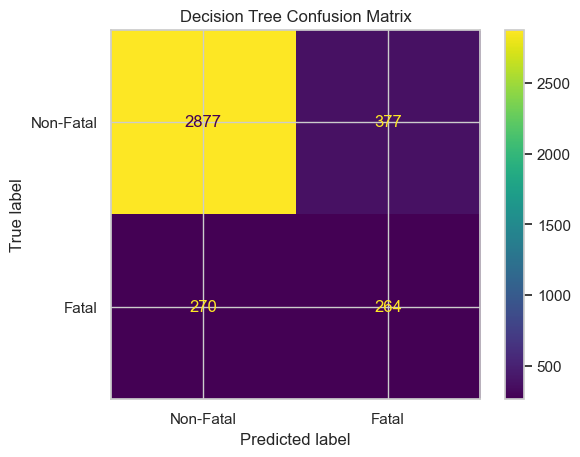

In [81]:
cm_alex = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_alex, display_labels=["Non-Fatal", "Fatal"])
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

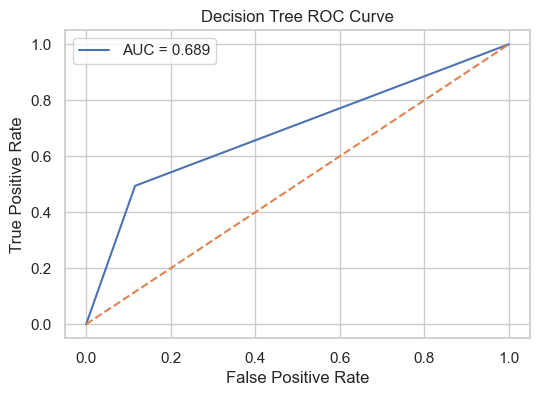

AUC: 0.6892623081013514


In [82]:
y_prob = best_dt.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

# Neural Network


In [84]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


In [85]:
# Initialize Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),   
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=89
)

In [86]:
# Train model
nn_model.fit(X_resampled, y_resampled)

# Predictions
y_pred_nn = nn_model.predict(X_test_processed)

# Accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_nn):.4f}")



Accuracy Score: 0.8535


c:\Users\yaksh\anaconda3\envs\ml\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


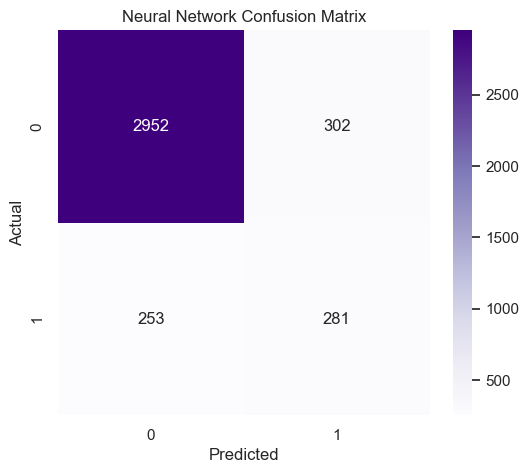

In [87]:
# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [88]:

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3254
           1       0.48      0.53      0.50       534

    accuracy                           0.85      3788
   macro avg       0.70      0.72      0.71      3788
weighted avg       0.86      0.85      0.86      3788



In [89]:
param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,), (100,50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive']
}

grid_nn = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=89),
    param_grid_nn,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_nn.fit(X_resampled, y_resampled)

print("Best Parameters:", grid_nn.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}


c:\Users\yaksh\anaconda3\envs\ml\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [90]:
best_nn = grid_nn.best_estimator_

# Final Predictions
y_pred_best_nn = best_nn.predict(X_test_processed)

print("\nFinal Model Evaluation (Tuned)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_nn):.4f}")
print(classification_report(y_test, y_pred_best_nn))



Final Model Evaluation (Tuned)
Accuracy: 0.8622
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3254
           1       0.51      0.53      0.52       534

    accuracy                           0.86      3788
   macro avg       0.72      0.72      0.72      3788
weighted avg       0.86      0.86      0.86      3788



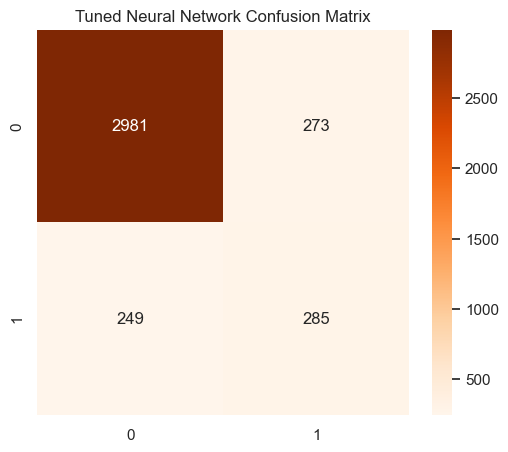

In [91]:

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best_nn), annot=True, fmt='d', cmap='Oranges')
plt.title('Tuned Neural Network Confusion Matrix')
plt.show()

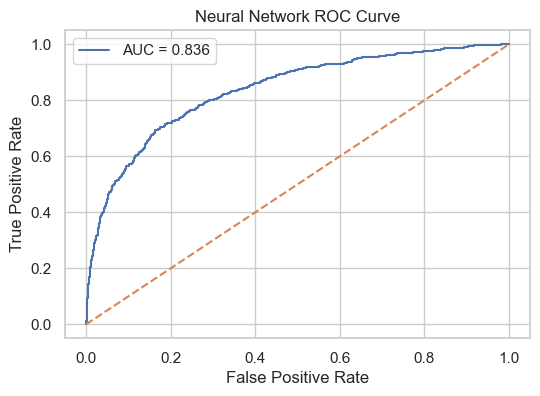

AUC: 0.8359921180270204


In [92]:
from sklearn.metrics import roc_curve, auc

y_prob_nn = best_nn.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [93]:
joblib.dump(best_nn, './model/neural_network_ksi_model.pkl')
print("Model saved as 'neural_network_ksi_model.pkl'")

Model saved as 'neural_network_ksi_model.pkl'


In [ ]:
from sklearn.svm import  SVC
from sklearn.inspection import DecisionBoundaryDisplay;
from mlxtend.plotting import plot_decision_regions

In [110]:
# through the plotting it was observed that data cannot be linearly seperable, we are currenlty choosing the SVM with rbf kernel

svm = SVC(kernel='rbf' ,C=2)
svm.fit(X_resampled, y_resampled)

SVC(C=2)

In [111]:

# Predictions
y_pred_svm = svm.predict(X_test_processed)

# Accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")


Accuracy Score: 0.8664


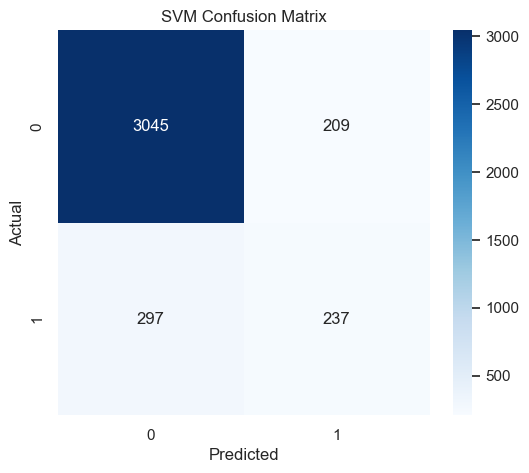

In [114]:
# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [116]:

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3254
           1       0.53      0.44      0.48       534

    accuracy                           0.87      3788
   macro avg       0.72      0.69      0.70      3788
weighted avg       0.86      0.87      0.86      3788



In [123]:

param_grid_svm = {
    'C': [0.1, 1,10,100],
    'kernel': ['poly', 'rbf'],

}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=3,
    scoring='recall',
    n_jobs=-1,   # 👈 VERY IMPORTANT
    verbose=2
)
grid_svm.fit(X_resampled, y_resampled)

print("Best Parameters:", grid_svm.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 10, 'kernel': 'poly'}


In [124]:
best_svm = grid_svm.best_estimator_

# Final Predictions
y_pred_best_svm = best_svm.predict(X_test_processed)

print("\nFinal Model Evaluation (Tuned)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(classification_report(y_test, y_pred_best_svm))


Final Model Evaluation (Tuned)
Accuracy: 0.8648
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3254
           1       0.52      0.56      0.54       534

    accuracy                           0.86      3788
   macro avg       0.72      0.74      0.73      3788
weighted avg       0.87      0.86      0.87      3788



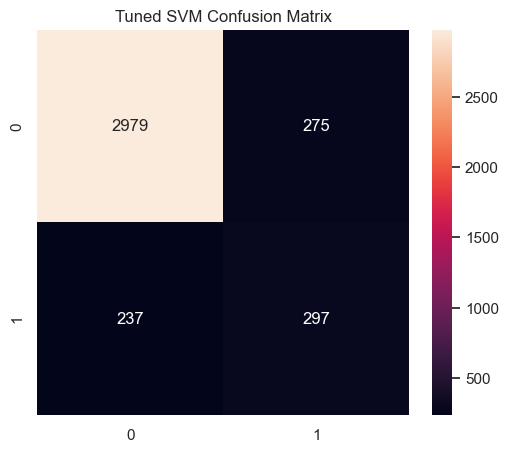

In [126]:

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best_svm), annot=True, fmt='d',)
plt.title('Tuned SVM Confusion Matrix')
plt.show()

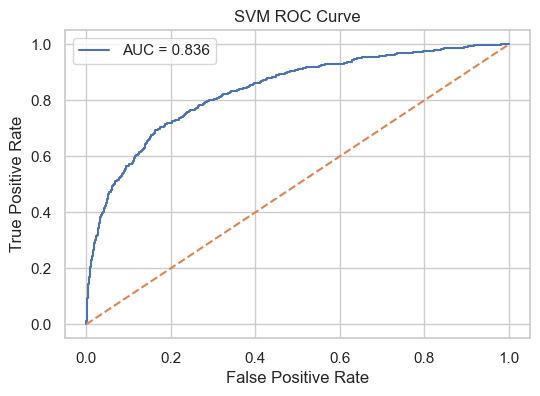

AUC: 0.8359921180270204


In [127]:
from sklearn.metrics import roc_curve, auc

y_prob_svm = best_nn.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [128]:

joblib.dump(best_nn, './model/svm_model.pkl')


['./model/svm_model.pkl']